# Notebook 03 — Model Training MLflow

## Imports et configuration

In [67]:
import os
import json
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

import mlflow
import mlflow.sklearn

from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV,
    GridSearchCV,
    cross_val_score
)

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "TARGET"
CLIENT_ID = "SK_ID_CURR"

pd.set_option("display.max_columns", 200)

### Configuration des chemins

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "application_train_enriched.parquet"
REPORTS_PATH = PROJECT_ROOT / "reports"
MODELS_PATH = PROJECT_ROOT / "models"

REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print("Dataset :", DATA_PATH)
print("Rapports :", REPORTS_PATH)
print("Modèles :", MODELS_PATH)

Dataset : /Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/data/processed/application_train_enriched.parquet
Rapports : /Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/reports
Modèles : /Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/models


### Configurer MLflow

In [3]:
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
experiment_name = "credit_scoring_training"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(experiment_name)

print("Tracking URI :", mlflow.get_tracking_uri())
print("Expérience   :", experiment_name)

Tracking URI : http://127.0.0.1:5000
Expérience   : credit_scoring_training


## Chargement et préparation des données

### Charger Dataset

In [4]:
train = pd.read_parquet(DATA_PATH)

test = pd.read_parquet(
    "../data/processed/application_test_enriched.parquet"
)

print("Train :", train.shape)
print("Test  :", test.shape)

Train : (307511, 543)
Test  : (48744, 542)


### Préparer X et y

In [5]:
X = train.drop(
    columns=[TARGET, CLIENT_ID]
)

y = train[TARGET].astype("int8")

In [6]:
# prédictions Kaggle
X_test = test.drop(
    columns=[CLIENT_ID]
)

test_ids = test[CLIENT_ID].copy()

In [7]:
print("X :", X.shape)
print("y :", y.shape)

print(y.value_counts())
print(y.value_counts(normalize=True))

X : (307511, 541)
y : (307511,)
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


### Convertir booléens en nombres
Après get_dummies, certaines colonnes peuvent être de type booléen.

In [8]:
bool_columns = X.select_dtypes(
    include="bool"
).columns

X[bool_columns] = X[bool_columns].astype("int8")
X_test[bool_columns] = X_test[bool_columns].astype("int8")

print("Colonnes booléennes converties :", len(bool_columns))

Colonnes booléennes converties : 131


In [9]:
print(X.dtypes.value_counts())

float64    367
int8       131
int64       43
Name: count, dtype: int64


### Nettoyage des noms de colonnes

In [10]:
import re


def clean_feature_names(columns):
    cleaned_columns = []
    name_counts = {}

    for column in columns:
        clean_name = str(column)

        # Remplace les caractères spéciaux par "_"
        clean_name = re.sub(
            r"[^A-Za-z0-9_]+",
            "_",
            clean_name,
        )

        # Supprime les "_" répétés
        clean_name = re.sub(
            r"_+",
            "_",
            clean_name,
        )

        clean_name = clean_name.strip("_")

        if not clean_name:
            clean_name = "feature"

        # Évite les doublons après nettoyage
        if clean_name in name_counts:
            name_counts[clean_name] += 1
            clean_name = (
                f"{clean_name}_{name_counts[clean_name]}"
            )
        else:
            name_counts[clean_name] = 0

        cleaned_columns.append(clean_name)

    return cleaned_columns

In [11]:
original_feature_names = X.columns.tolist()

X.columns = clean_feature_names(X.columns)

feature_name_mapping = dict(
    zip(
        original_feature_names,
        X.columns,
    )
)

### Split
Utilise une séparation stratifiée pour préserver la proportion de clients en défaut.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train :", X_train.shape)
print("Test final :", X_test.shape)

print("\nRépartition train :")
print(y_train.value_counts(normalize=True))

print("\nRépartition test :")
print(y_test.value_counts(normalize=True))

Train : (246008, 541)
Test final : (61503, 541)

Répartition train :
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Répartition test :
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


### Validation croisée stratifiée

In [13]:
N_SPLITS = 3

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

## Définition des fonctions d'évaluation

### Définir le coût métier

On suppose :

- faux positif : coût de 1 ;
- faux négatif : coût de 10.

Un faux négatif correspond ici à un client réellement risqué que le modèle classe comme bon client.

In [14]:
FN_COST = 10
FP_COST = 1

In [15]:
def compute_business_cost(
    y_true,
    y_pred,
    fn_cost=FN_COST,
    fp_cost=FP_COST,
):
    """
    Calcule le coût métier total :
    coût = FN_COST * FN + FP_COST * FP
    """
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    total_cost = fn_cost * fn + fp_cost * fp

    return {
        "business_cost": float(total_cost),
        "normalized_business_cost": float(total_cost / len(y_true)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

### Score Métier pour Validation croisée
cross_validate cherche à maximiser les scores. On renvoie donc l’opposé du coût métier.

In [16]:
def business_cost_score(y_true, y_pred):
    result = compute_business_cost(y_true, y_pred)

    return -result["normalized_business_cost"]

In [17]:
business_scorer = make_scorer(
    business_cost_score,
    greater_is_better=True,
)

### Métriques communes au modèles

In [18]:
scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "business_cost": business_scorer,
}

### Fonction commune de Validation croisée

In [19]:
def evaluate_model_cv(
    model,
    model_name,
    X_data=X_train,
    y_data=y_train,
):
    """
    Évalue un modèle avec une validation croisée stratifiée.

    Retourne :
    - les métriques agrégées ;
    - les résultats détaillés des folds ;
    - les probabilités out-of-fold ;
    - les prédictions out-of-fold.
    """

    start_time = time.time()

    # Métriques calculées séparément sur chaque fold
    cv_results = cross_validate(
        estimator=model,
        X=X_data,
        y=y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    # Probabilités out-of-fold
    oof_probabilities = cross_val_predict(
        estimator=model,
        X=X_data,
        y=y_data,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    # Prédictions avec le seuil par défaut
    oof_predictions = (
        oof_probabilities >= 0.50
    ).astype(int)

    total_time = time.time() - start_time

    # Matrice de confusion globale out-of-fold
    tn, fp, fn, tp = confusion_matrix(
        y_data,
        oof_predictions,
        labels=[0, 1],
    ).ravel()

    # Résultats agrégés
    results = {
        "model": model_name,

        "mean_cv_roc_auc": (
            cv_results["test_roc_auc"].mean()
        ),
        "std_cv_roc_auc": (
            cv_results["test_roc_auc"].std()
        ),

        "mean_cv_recall": (
            cv_results["test_recall"].mean()
        ),
        "std_cv_recall": (
            cv_results["test_recall"].std()
        ),

        "mean_cv_precision": (
            cv_results["test_precision"].mean()
        ),
        "std_cv_precision": (
            cv_results["test_precision"].std()
        ),

        "mean_cv_f1": (
            cv_results["test_f1"].mean()
        ),
        "std_cv_f1": (
            cv_results["test_f1"].std()
        ),

        # Le scorer métier renvoie un coût négatif
        "mean_cv_business_cost": (
            -cv_results["test_business_cost"].mean()
        ),
        "std_cv_business_cost": (
            cv_results["test_business_cost"].std()
        ),

        "oof_roc_auc": roc_auc_score(
            y_data,
            oof_probabilities,
        ),

        "oof_accuracy": accuracy_score(
            y_data,
            oof_predictions,
        ),

        "oof_precision": precision_score(
            y_data,
            oof_predictions,
            zero_division=0,
        ),

        "oof_recall": recall_score(
            y_data,
            oof_predictions,
            zero_division=0,
        ),

        "oof_f1": f1_score(
            y_data,
            oof_predictions,
            zero_division=0,
        ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),

        "mean_fit_time": (
            cv_results["fit_time"].mean()
        ),
        "std_fit_time": (
            cv_results["fit_time"].std()
        ),

        "mean_score_time": (
            cv_results["score_time"].mean()
        ),

        "total_cv_time": total_time,
    }

    # Tableau détaillé, une ligne par fold
    fold_results_df = pd.DataFrame(
        {
            "fold": np.arange(
                1,
                len(cv_results["test_roc_auc"]) + 1,
            ),
            "roc_auc": cv_results["test_roc_auc"],
            "recall": cv_results["test_recall"],
            "precision": cv_results["test_precision"],
            "f1": cv_results["test_f1"],

            # Conversion du score négatif en coût positif
            "normalized_business_cost": (
                -cv_results["test_business_cost"]
            ),

            "fit_time": cv_results["fit_time"],
            "score_time": cv_results["score_time"],
        }
    )

    return (
        results,
        fold_results_df,
        oof_probabilities,
        oof_predictions,
    )

### Tableau des résultats

In [20]:
model_results = []

### Fonction pour créer les artefacts

In [21]:
def create_model_artifacts(
    model_name,
    y_true,
    oof_probabilities,
    oof_predictions,
    fold_results_df,
):
    """
    Crée les artefacts associés à un run MLflow.
    """

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    model_report_path = (
        REPORTS_PATH / safe_model_name
    )

    model_report_path.mkdir(
        parents=True,
        exist_ok=True,
    )

    # 1. Résultats détaillés des folds
    fold_results_path = (
        model_report_path
        / "cross_validation_results.csv"
    )

    fold_results_df.to_csv(
        fold_results_path,
        index=False,
    )

    # 2. Prédictions out-of-fold
    oof_results_df = pd.DataFrame(
        {
            "y_true": np.asarray(y_true),
            "default_probability": (
                oof_probabilities
            ),
            "prediction_threshold_050": (
                oof_predictions
            ),
        }
    )

    oof_results_path = (
        model_report_path
        / "oof_predictions.csv"
    )

    oof_results_df.to_csv(
        oof_results_path,
        index=False,
    )

    # 3. Matrice de confusion
    confusion_matrix_path = (
        model_report_path
        / "confusion_matrix.png"
    )

    plt.figure(figsize=(7, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        oof_predictions,
        labels=[0, 1],
        display_labels=[
            "Client sans défaut",
            "Client en défaut",
        ],
        values_format="d",
    )

    plt.title(
        f"Matrice de confusion — {model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        confusion_matrix_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close()

    # 4. Courbe ROC
    roc_curve_path = (
        model_report_path
        / "roc_curve.png"
    )

    plt.figure(figsize=(8, 6))

    RocCurveDisplay.from_predictions(
        y_true,
        oof_probabilities,
        name=model_name,
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Modèle aléatoire",
    )

    plt.title(
        f"Courbe ROC — {model_name}"
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        roc_curve_path,
        dpi=150,
        bbox_inches="tight",
    )

    plt.close()

    return {
        "fold_results": fold_results_path,
        "oof_predictions": oof_results_path,
        "confusion_matrix": confusion_matrix_path,
        "roc_curve": roc_curve_path,
        "artifact_directory": model_report_path,
    }

### Fonction de journalisation MLflow

In [22]:
def log_common_mlflow_information(
    model_name,
    model,
    metrics,
    artifacts,
):
    """
    Enregistre les éléments communs à tous les modèles.
    """

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_comparison",
            "model_name": model_name,
            "model_family": type(
                model.named_steps["model"]
                if isinstance(model, Pipeline)
                else model
            ).__name__,
            "validation_strategy": (
                "StratifiedKFold"
            ),
            "dataset": (
                "application_train_enriched"
            ),
            "target": "TARGET",
            "threshold": "0.50",
            "class_imbalance": "true",
            "business_objective": (
                "minimize_false_negative_cost"
            ),
            "run_type": "baseline_model",
        }
    )

    mlflow.log_params(
        {
            "n_splits": N_SPLITS,
            "random_state": RANDOM_STATE,
            "decision_threshold": 0.50,

            "false_negative_cost": FN_COST,
            "false_positive_cost": FP_COST,

            "number_training_rows": (
                X_train.shape[0]
            ),
            "number_features": (
                X_train.shape[1]
            ),

            "positive_class_count": int(
                (y_train == 1).sum()
            ),
            "negative_class_count": int(
                (y_train == 0).sum()
            ),

            "positive_class_rate": float(
                y_train.mean()
            ),
        }
    )

    # Paramètres complets de l’estimateur
    model_parameters = model.get_params()

    compatible_parameters = {}

    for key, value in model_parameters.items():

        if isinstance(
            value,
            (
                str,
                int,
                float,
                bool,
                type(None),
                np.integer,
                np.floating,
            ),
        ):
            compatible_parameters[
                f"estimator_{key}"
            ] = value

    mlflow.log_params(
        compatible_parameters
    )

    mlflow.log_metrics(
        {
            key: float(value)
            for key, value in metrics.items()
            if (
                key != "model"
                and isinstance(
                    value,
                    (
                        int,
                        float,
                        np.integer,
                        np.floating,
                    ),
                )
            )
        }
    )

    # On peut enregistrer le dossier entier
    mlflow.log_artifacts(
        local_dir=str(
            artifacts["artifact_directory"]
        ),
        artifact_path="evaluation",
    )

## Préprocessing

### Pipelines de préparartion

La régression logistique et le MLP ont besoin d’une standardisation.

Les modèles d’arbres n’en ont pas besoin.

In [23]:
linear_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

In [24]:
tree_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
    ]
)

## Runs

### Run 1 — Baseline naïve
Une baseline naïve permet de vérifier qu’un vrai modèle fait mieux qu’une stratégie triviale.

In [25]:
dummy_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "model",
            DummyClassifier(
                strategy="prior",
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [26]:
with mlflow.start_run(
    run_name="01_DummyClassifier"
) as run:

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_comparison",
            "model_name": "DummyClassifier",
            "model_family": "Baseline",
            "validation_strategy": "StratifiedKFold",
            "run_type": "baseline_reference",
            "status": "reference",
            "class_imbalance_management": "none",
        }
    )

    (
        dummy_metrics,
        dummy_fold_results,
        dummy_oof_probabilities,
        dummy_oof_predictions,
    ) = evaluate_model_cv(
        model=dummy_model,
        model_name="DummyClassifier",
    )

    dummy_artifacts = create_model_artifacts(
        model_name="DummyClassifier",
        y_true=y_train,
        oof_probabilities=dummy_oof_probabilities,
        oof_predictions=dummy_oof_predictions,
        fold_results_df=dummy_fold_results,
    )

    log_common_mlflow_information(
        model_name="DummyClassifier",
        model=dummy_model,
        metrics=dummy_metrics,
        artifacts=dummy_artifacts,
    )

    mlflow.log_params(
        {
            "strategy": "prior",
            "class_weight": "none",
            "preprocessing_imputation": "median",
            "preprocessing_scaling": "none",
        }
    )

    model_results.append(dummy_metrics)

    dummy_run_id = run.info.run_id

print("Run terminé :", dummy_run_id)

dummy_metrics

/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicte

🏃 View run 01_DummyClassifier at: http://127.0.0.1:5000/#/experiments/1/runs/1695d3c25fc24bfe9ae6439fd621fc70
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run terminé : 1695d3c25fc24bfe9ae6439fd621fc70


{'model': 'DummyClassifier',
 'mean_cv_roc_auc': np.float64(0.5),
 'std_cv_roc_auc': np.float64(0.0),
 'mean_cv_recall': np.float64(0.0),
 'std_cv_recall': np.float64(0.0),
 'mean_cv_precision': np.float64(0.0),
 'std_cv_precision': np.float64(0.0),
 'mean_cv_f1': np.float64(0.0),
 'std_cv_f1': np.float64(0.0),
 'mean_cv_business_cost': np.float64(0.8072908198374166),
 'std_cv_business_cost': np.float64(4.640850163586693e-06),
 'oof_roc_auc': np.float64(0.4999985260389951),
 'oof_accuracy': 0.9192709180189262,
 'oof_precision': 0.0,
 'oof_recall': 0.0,
 'oof_f1': 0.0,
 'tn': 226148,
 'fp': 0,
 'fn': 19860,
 'tp': 0,
 'mean_fit_time': np.float64(25.828714688618977),
 'std_fit_time': np.float64(0.4726893756273843),
 'mean_score_time': np.float64(2.011360247929891),
 'total_cv_time': 60.72528696060181}

<Figure size 700x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### Run 2 — Régression logistique
La régression logistique constitue une baseline interprétable.

In [27]:
logistic_model = Pipeline(
    steps=[
        ("preprocessing", linear_preprocessor),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                solver="liblinear",
                random_state=RANDOM_STATE
            )
        )
    ]
)

Le pipeline garantit que l’imputation et la standardisation sont apprises uniquement sur les données utilisées pour l’entraînement.

In [28]:
with mlflow.start_run(
    run_name="02_LogisticRegression"
) as run:

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_comparison",
            "model_name": "LogisticRegression",
            "model_family": "Linear Model",
            "validation_strategy": "StratifiedKFold",
            "run_type": "baseline_model",
            "status": "candidate",
            "class_imbalance_management": "class_weight",
        }
    )

    (
        logistic_metrics,
        logistic_fold_results,
        logistic_oof_probabilities,
        logistic_oof_predictions,
    ) = evaluate_model_cv(
        model=logistic_model,
        model_name="LogisticRegression",
    )

    logistic_artifacts = create_model_artifacts(
        model_name="LogisticRegression",
        y_true=y_train,
        oof_probabilities=logistic_oof_probabilities,
        oof_predictions=logistic_oof_predictions,
        fold_results_df=logistic_fold_results,
    )

    log_common_mlflow_information(
        model_name="LogisticRegression",
        model=logistic_model,
        metrics=logistic_metrics,
        artifacts=logistic_artifacts,
    )

    mlflow.log_params(
        {
            "C": 1.0,
            "class_weight": "balanced",
            "solver": "saga",
            "penalty": "l2",
            "max_iter": 500,
            "preprocessing_imputation": "median",
            "missing_value_indicators": True,
            "preprocessing_scaling": "StandardScaler",
        }
    )

    model_results.append(logistic_metrics)

    logistic_run_id = run.info.run_id

print("Run terminé :", logistic_run_id)

logistic_metrics

🏃 View run 02_LogisticRegression at: http://127.0.0.1:5000/#/experiments/1/runs/92b096afe2fa4567aab1e78351568dea
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


KeyboardInterrupt: 

### Run 3 - Random Forest

In [29]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessing", tree_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [30]:
with mlflow.start_run(
    run_name="03_RandomForest"
) as run:

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_comparison",
            "model_name": "RandomForest",
            "model_family": "Bagging Ensemble",
            "validation_strategy": "StratifiedKFold",
            "run_type": "baseline_model",
            "status": "challenger",
            "class_imbalance_management": (
                "balanced_subsample"
            ),
        }
    )

    (
        random_forest_metrics,
        random_forest_fold_results,
        random_forest_oof_probabilities,
        random_forest_oof_predictions,
    ) = evaluate_model_cv(
        model=random_forest_model,
        model_name="RandomForest",
    )

    random_forest_artifacts = create_model_artifacts(
        model_name="RandomForest",
        y_true=y_train,
        oof_probabilities=random_forest_oof_probabilities,
        oof_predictions=random_forest_oof_predictions,
        fold_results_df=random_forest_fold_results,
    )

    log_common_mlflow_information(
        model_name="RandomForest",
        model=random_forest_model,
        metrics=random_forest_metrics,
        artifacts=random_forest_artifacts,
    )

    mlflow.log_params(
        {
            "n_estimators": 300,
            "max_depth": 15,
            "min_samples_split": 10,
            "min_samples_leaf": 5,
            "max_features": "sqrt",
            "class_weight": "balanced_subsample",
            "bootstrap": True,
            "criterion": "gini",
            "preprocessing_imputation": "median",
            "preprocessing_scaling": "none",
        }
    )

    model_results.append(random_forest_metrics)

    random_forest_run_id = run.info.run_id

print("Run terminé :", random_forest_run_id)

random_forest_metrics

🏃 View run 03_RandomForest at: http://127.0.0.1:5000/#/experiments/1/runs/737ded2be3ef45a6a0ccdda43b6652fe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run terminé : 737ded2be3ef45a6a0ccdda43b6652fe


{'model': 'RandomForest',
 'mean_cv_roc_auc': np.float64(0.7577056421048217),
 'std_cv_roc_auc': np.float64(0.0012660191399554313),
 'mean_cv_recall': np.float64(0.34159113796576035),
 'std_cv_recall': np.float64(0.007565280170427283),
 'mean_cv_precision': np.float64(0.25466060233850424),
 'std_cv_precision': np.float64(0.002243984630417258),
 'mean_cv_f1': np.float64(0.2917719951125791),
 'std_cv_f1': np.float64(0.00408875514639349),
 'mean_cv_business_cost': np.float64(0.612228049993972),
 'std_cv_business_cost': np.float64(0.005147542578622981),
 'oof_roc_auc': np.float64(0.7576903663832439),
 'oof_accuracy': 0.8661466293779064,
 'oof_precision': 0.2546833352104216,
 'oof_recall': 0.34159113796576035,
 'oof_f1': 0.29180377228638404,
 'tn': 206295,
 'fp': 19853,
 'fn': 13076,
 'tp': 6784,
 'mean_fit_time': np.float64(117.05905659993489),
 'std_fit_time': np.float64(1.1903850150925328),
 'mean_score_time': np.float64(2.5486454168955484),
 'total_cv_time': 258.3188011646271}

<Figure size 700x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### Calcul du poids pour XGBoost et LightGBM

In [31]:
number_negative = int((y_train == 0).sum())
number_positive = int((y_train == 1).sum())

scale_pos_weight = number_negative / number_positive

print("Nombre de classe 0 :", number_negative)
print("Nombre de classe 1 :", number_positive)
print("scale_pos_weight :", scale_pos_weight)

Nombre de classe 0 : 226148
Nombre de classe 1 : 19860
scale_pos_weight : 11.38710976837865


XGBoost et LightGBM proposent scale_pos_weight pour donner davantage de poids à la classe minoritaire. Pour LightGBM, il ne faut pas utiliser simultanément is_unbalance et scale_pos_weight.

### Run 4 - XGBoost
XGBoost sait gérer les valeurs manquantes. On peut donc l’utiliser sans imputation.

In [32]:
xgboost_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",

    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=0.10,
    reg_lambda=1.0,

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [33]:
with mlflow.start_run(
    run_name="04_XGBoost"
) as run:

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_comparison",
            "model_name": "XGBoost",
            "model_family": "Gradient Boosting",
            "validation_strategy": (
                "StratifiedKFold"
            ),
            "run_type": "baseline_model",
            "status": "challenger",
        }
    )

    (
        xgboost_metrics,
        xgboost_fold_results,
        xgboost_oof_probabilities,
        xgboost_oof_predictions,
    ) = evaluate_model_cv(
        model=xgboost_model,
        model_name="XGBoost",
    )

    xgboost_artifacts = (
        create_model_artifacts(
            model_name="XGBoost",
            y_true=y_train,
            oof_probabilities=(
                xgboost_oof_probabilities
            ),
            oof_predictions=(
                xgboost_oof_predictions
            ),
            fold_results_df=(
                xgboost_fold_results
            ),
        )
    )

    log_common_mlflow_information(
        model_name="XGBoost",
        model=xgboost_model,
        metrics=xgboost_metrics,
        artifacts=xgboost_artifacts,
    )

    mlflow.log_params(
        {
            "objective": (
                "binary:logistic"
            ),
            "eval_metric": "auc",
            "n_estimators": 400,
            "learning_rate": 0.05,
            "max_depth": 6,
            "min_child_weight": 5,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.10,
            "reg_lambda": 1.0,
            "scale_pos_weight": (
                scale_pos_weight
            ),
            "tree_method": "hist",
        }
    )

    model_results.append(
        xgboost_metrics
    )

    xgboost_run_id = run.info.run_id



🏃 View run 04_XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/30a31899c352488493f4e719c0d98d91
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


<Figure size 700x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### Run 5 — LightGBM baseline
LightGBM peut gérer nativement les valeurs manquantes. Il n’a donc pas besoin du même pipeline que la régression logistique.

cross_validate permet de calculer plusieurs métriques sur chaque pli, tandis que StratifiedKFold préserve la répartition des classes.

In [34]:
lightgbm_model = LGBMClassifier(
    objective="binary",

    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=0.10,
    reg_lambda=1.0,

    scale_pos_weight=scale_pos_weight,

    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

In [35]:
with mlflow.start_run(
    run_name="05_LightGBM"
) as run:

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_comparison",
            "model_name": "LightGBM",
            "model_family": "Gradient Boosting",
            "validation_strategy": (
                "StratifiedKFold"
            ),
            "run_type": "baseline_model",
            "status": "candidate",
        }
    )

    (
        lightgbm_metrics,
        lightgbm_fold_results,
        lightgbm_oof_probabilities,
        lightgbm_oof_predictions,
    ) = evaluate_model_cv(
        model=lightgbm_model,
        model_name="LightGBM",
    )

    lightgbm_artifacts = (
        create_model_artifacts(
            model_name="LightGBM",
            y_true=y_train,
            oof_probabilities=(
                lightgbm_oof_probabilities
            ),
            oof_predictions=(
                lightgbm_oof_predictions
            ),
            fold_results_df=(
                lightgbm_fold_results
            ),
        )
    )

    log_common_mlflow_information(
        model_name="LightGBM",
        model=lightgbm_model,
        metrics=lightgbm_metrics,
        artifacts=lightgbm_artifacts,
    )

    # Paramètres métier ou spécifiques
    mlflow.log_params(
        {
            "objective": "binary",
            "n_estimators": 500,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": -1,
            "min_child_samples": 30,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.10,
            "reg_lambda": 1.0,
            "scale_pos_weight": (
                scale_pos_weight
            ),
        }
    )

    model_results.append(
        lightgbm_metrics
    )

    lightgbm_run_id = run.info.run_id

print("Run ID :", lightgbm_run_id)

lightgbm_metrics

🏃 View run 05_LightGBM at: http://127.0.0.1:5000/#/experiments/1/runs/cf996a2cf8a747009cfdbd064d2c37d1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run ID : cf996a2cf8a747009cfdbd064d2c37d1


{'model': 'LightGBM',
 'mean_cv_roc_auc': np.float64(0.782941333680875),
 'std_cv_roc_auc': np.float64(0.0015732042535824933),
 'mean_cv_recall': np.float64(0.6379657603222557),
 'std_cv_recall': np.float64(0.0022484505097448214),
 'mean_cv_precision': np.float64(0.20136237691453293),
 'std_cv_precision': np.float64(0.001077060862369802),
 'mean_cv_f1': np.float64(0.306107273094415),
 'std_cv_f1': np.float64(0.0015031689450656616),
 'mean_cv_business_cost': np.float64(0.4965367004719789),
 'std_cv_business_cost': np.float64(0.0024625417419692434),
 'oof_roc_auc': np.float64(0.7829313863938276),
 'oof_accuracy': 0.7665035283405418,
 'oof_precision': 0.20136041448142145,
 'oof_recall': 0.6379657603222558,
 'oof_f1': 0.3061051919499408,
 'tn': 175896,
 'fp': 50252,
 'fn': 7190,
 'tp': 12670,
 'mean_fit_time': np.float64(36.758441050847374),
 'std_fit_time': np.float64(0.6055022562476907),
 'mean_score_time': np.float64(1.977646271387736),
 'total_cv_time': 78.7246561050415}

<Figure size 700x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### Run 6 - MLPClassifier

In [36]:
mlp_model = Pipeline(
    steps=[
        ("preprocessing", linear_preprocessor),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                batch_size=512,
                learning_rate_init=0.001,
                max_iter=100,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=10,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [37]:
with mlflow.start_run(
    run_name="06_MLP"
) as run:

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_comparison",
            "model_name": "MLP",
            "model_family": "Neural Network",
            "validation_strategy": "StratifiedKFold",
            "run_type": "baseline_model",
            "status": "challenger",
            "class_imbalance_management": (
                "decision_threshold_only"
            ),
        }
    )

    (
        mlp_metrics,
        mlp_fold_results,
        mlp_oof_probabilities,
        mlp_oof_predictions,
    ) = evaluate_model_cv(
        model=mlp_model,
        model_name="MLP",
    )

    mlp_artifacts = create_model_artifacts(
        model_name="MLP",
        y_true=y_train,
        oof_probabilities=mlp_oof_probabilities,
        oof_predictions=mlp_oof_predictions,
        fold_results_df=mlp_fold_results,
    )

    log_common_mlflow_information(
        model_name="MLP",
        model=mlp_model,
        metrics=mlp_metrics,
        artifacts=mlp_artifacts,
    )

    mlflow.log_params(
        {
            "hidden_layer_1": 128,
            "hidden_layer_2": 64,
            "hidden_layer_sizes": "128_64",
            "activation": "relu",
            "solver": "adam",
            "alpha": 0.0001,
            "batch_size": 512,
            "learning_rate": "constant",
            "learning_rate_init": 0.001,
            "max_iter": 100,
            "early_stopping": True,
            "validation_fraction": 0.10,
            "n_iter_no_change": 10,
            "preprocessing_imputation": "median",
            "missing_value_indicators": True,
            "preprocessing_scaling": "StandardScaler",
        }
    )

    model_results.append(mlp_metrics)

    mlp_run_id = run.info.run_id

print("Run terminé :", mlp_run_id)

mlp_metrics

/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encounter

🏃 View run 06_MLP at: http://127.0.0.1:5000/#/experiments/1/runs/732ed4228bd042579e7a051404eea64d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run terminé : 732ed4228bd042579e7a051404eea64d


{'model': 'MLP',
 'mean_cv_roc_auc': np.float64(0.7540238300050551),
 'std_cv_roc_auc': np.float64(0.0015409864369185502),
 'mean_cv_recall': np.float64(0.02905337361530715),
 'std_cv_recall': np.float64(0.008827349041067549),
 'mean_cv_precision': np.float64(0.4951056676901507),
 'std_cv_precision': np.float64(0.015088294559052081),
 'mean_cv_f1': np.float64(0.05456899262389576),
 'std_cv_f1': np.float64(0.01567902126294309),
 'mean_cv_business_cost': np.float64(0.7862711481922885),
 'std_cv_business_cost': np.float64(0.0062559126174691814),
 'oof_roc_auc': np.float64(0.7538073813241855),
 'oof_accuracy': 0.9191814900328444,
 'oof_precision': 0.4906462585034014,
 'oof_recall': 0.02905337361530715,
 'oof_f1': 0.0548583380870888,
 'tn': 225549,
 'fp': 599,
 'fn': 19283,
 'tp': 577,
 'mean_fit_time': np.float64(51.67100842793783),
 'std_fit_time': np.float64(1.8624656865105236),
 'mean_score_time': np.float64(2.2784529527028403),
 'total_cv_time': 91.15389609336853}

<Figure size 700x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

Les versions récentes de Scikit-learn permettent également de passer des poids individuels à MLPClassifier.fit, mais ce paramètre n’existe que depuis Scikit-learn 1.7. Le code ci-dessus reste donc plus compatible avec les environnements plus anciens.

## Comparaison des modèles

In [38]:
comparison_df = pd.DataFrame(model_results)

comparison_df = comparison_df.drop_duplicates(
    subset="model",
    keep="last",
)

comparison_df = comparison_df.sort_values(
    by=[
        "mean_cv_business_cost",
        "mean_cv_roc_auc",
    ],
    ascending=[True, False],
).reset_index(drop=True)

comparison_df

,model,mean_cv_roc_auc,std_cv_roc_auc,mean_cv_recall,std_cv_recall,mean_cv_precision,std_cv_precision,mean_cv_f1,std_cv_f1,mean_cv_business_cost,std_cv_business_cost,oof_roc_auc,oof_accuracy,oof_precision,oof_recall,oof_f1,tn,fp,fn,tp,mean_fit_time,std_fit_time,mean_score_time,total_cv_time
0,LightGBM,0.782941,0.001573,0.637966,0.002248,0.201362,0.001077,0.306107,0.001503,0.496537,0.002463,0.782931,0.766504,0.201360,0.637966,0.306105,175896,50252,7190,12670,36.758441,0.605502,1.977646,78.724656
1,XGBoost,0.782876,0.001751,0.616012,0.002802,0.208425,0.000333,0.311467,0.000727,0.498858,0.001782,0.782864,0.780129,0.208423,0.616012,0.311464,179684,46464,7626,12234,53.312265,0.333165,2.228887,111.237371
2,RandomForest,0.757706,0.001266,0.341591,0.007565,0.254661,0.002244,0.291772,0.004089,0.612228,0.005148,0.757690,0.866147,0.254683,0.341591,0.291804,206295,19853,13076,6784,117.059057,1.190385,2.548645,258.318801
3,MLP,0.754024,0.001541,0.029053,0.008827,0.495106,0.015088,0.054569,0.015679,0.786271,0.006256,0.753807,0.919181,0.490646,0.029053,0.054858,225549,599,19283,577,51.671008,1.862466,2.278453,91.153896
4,DummyClassifier,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.807291,0.000005,0.499999,0.919271,0.000000,0.000000,0.000000,226148,0,19860,0,25.828715,0.472689,2.011360,60.725287


In [39]:
# Enregistrement CSV
comparison_path = REPORTS_PATH / "model_comparison.csv"

comparison_df.to_csv(
    comparison_path,
    index=False,
)

print("Résultats enregistrés dans :", comparison_path)

Résultats enregistrés dans : /Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/reports/model_comparison.csv


In [40]:
with mlflow.start_run(
    run_name="Model_Comparison_Summary"
):

    mlflow.set_tags(
        {
            "project": "Home Credit Default Risk",
            "project_step": "model_selection",
            "run_type": "comparison_summary",
            "validation_strategy": "StratifiedKFold",
            "selection_metric": (
                "normalized_business_cost"
            ),
        }
    )

    best_result = comparison_df.iloc[0]

    mlflow.log_params(
        {
            "number_of_models_compared": (
                len(comparison_df)
            ),
            "selected_model": (
                best_result["model"]
            ),
            "selection_metric": (
                "mean_cv_business_cost"
            ),
        }
    )

    mlflow.log_metrics(
        {
            "best_mean_cv_roc_auc": float(
                best_result[
                    "mean_cv_roc_auc"
                ]
            ),
            "best_mean_cv_recall": float(
                best_result[
                    "mean_cv_recall"
                ]
            ),
            "best_mean_cv_f1": float(
                best_result[
                    "mean_cv_f1"
                ]
            ),
            "best_mean_cv_business_cost": float(
                best_result[
                    "mean_cv_business_cost"
                ]
            ),
        }
    )

    mlflow.log_artifact(
        str(comparison_path),
        artifact_path="comparison",
    )

🏃 View run Model_Comparison_Summary at: http://127.0.0.1:5000/#/experiments/1/runs/82ea9fc7de724a60b45367908790986c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### Graphique du coût métier

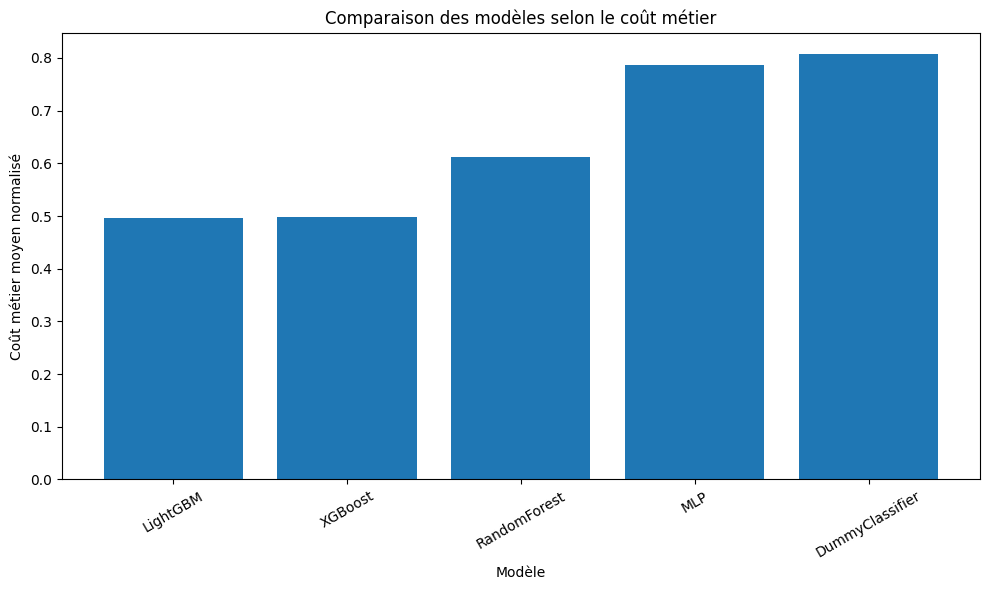

In [41]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["model"],
    comparison_df["mean_cv_business_cost"],
)

plt.xlabel("Modèle")
plt.ylabel("Coût métier moyen normalisé")
plt.title("Comparaison des modèles selon le coût métier")
plt.xticks(rotation=30)
plt.tight_layout()

comparison_plot_path = (
    REPORTS_PATH / "model_business_cost_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Sélection du modèle à optimiser

In [42]:
comparison_df[
    [
        "model",
        "mean_cv_roc_auc",
        "std_cv_roc_auc",
        "mean_cv_recall",
        "mean_cv_f1",
        "mean_cv_business_cost",
    ]
]

,model,mean_cv_roc_auc,std_cv_roc_auc,mean_cv_recall,mean_cv_f1,mean_cv_business_cost
0,LightGBM,0.782941,0.001573,0.637966,0.306107,0.496537
1,XGBoost,0.782876,0.001751,0.616012,0.311467,0.498858
2,RandomForest,0.757706,0.001266,0.341591,0.291772,0.612228
3,MLP,0.754024,0.001541,0.029053,0.054569,0.786271
4,DummyClassifier,0.500000,0.000000,0.000000,0.000000,0.807291


Les résultats de validation croisée montrent que LightGBM est le modèle le plus adapté à la problématique métier. Il obtient la meilleure ROC-AUC, avec une valeur moyenne de 0,783, ainsi que le coût métier normalisé le plus faible, égal à 0,497. XGBoost présente des performances très proches, mais son coût métier est légèrement supérieur et son temps d’entraînement est plus important. La régression logistique obtient le meilleur rappel, mais génère davantage de faux positifs, ce qui augmente le coût métier. Random Forest et MLP présentent un rappel trop faible et entraînent un nombre important de faux négatifs. LightGBM est donc sélectionné pour l’optimisation des hyperparamètres et du seuil de décision.

In [43]:
MODEL_TO_OPTIMIZE = "LightGBM"

## Optimisation des hyperparamètres LightGBM
Sur 307 000 lignes, une grosse GridSearchCV peut être très longue. Commence avec RandomizedSearchCV, qui teste un nombre limité de combinaisons.

In [44]:
# Grille de paramètres LightGBM
lightgbm_parameter_distribution = {
    "n_estimators": randint(300, 900),
    "learning_rate": loguniform(0.01, 0.20),
    "num_leaves": randint(15, 100),
    "max_depth": [-1, 5, 8, 12, 16],
    "min_child_samples": randint(10, 100),

    "subsample": uniform(0.65, 0.35),
    "colsample_bytree": uniform(0.65, 0.35),

    "reg_alpha": loguniform(1e-4, 10),
    "reg_lambda": loguniform(1e-3, 20),

    "scale_pos_weight": [
        1,
        scale_pos_weight / 2,
        scale_pos_weight,
        scale_pos_weight * 1.5,
    ],
}

In [45]:
def randomized_search_business_scorer(
    estimator,
    X_validation,
    y_validation,
):
    probabilities = estimator.predict_proba(X_validation)[:, 1]

    predictions = (probabilities >= 0.50).astype(int)

    result = compute_business_cost(
        y_true=y_validation,
        y_pred=predictions,
    )

    return -result["normalized_business_cost"]

In [46]:
N_ITER_SEARCH = 20

lightgbm_random_search = RandomizedSearchCV(
    estimator=lightgbm_model,
    param_distributions=lightgbm_parameter_distribution,

    n_iter=N_ITER_SEARCH,
    scoring=randomized_search_business_scorer,

    cv=cv,
    n_jobs=-1,
    verbose=2,

    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=False,
)

### Run 7 — Tracker la recherche d’hyperparamètres

In [47]:
with mlflow.start_run(
    run_name="07_LightGBM_Hyperparameter_Optimization"
):

    mlflow.log_params(
        {
            "model": "LightGBM",
            "search_method": "RandomizedSearchCV",
            "n_iter": N_ITER_SEARCH,
            "n_splits": N_SPLITS,
            "optimization_metric": "business_cost",
            "threshold_during_search": 0.50,
        }
    )

    start_time = time.time()

    lightgbm_random_search.fit(
        X_train,
        y_train,
    )

    optimization_time = time.time() - start_time

    best_lightgbm_model = (
        lightgbm_random_search.best_estimator_
    )

    best_lightgbm_params = (
        lightgbm_random_search.best_params_
    )

    mlflow.log_params(
        {
            f"best_{parameter}": value
            for parameter, value
            in best_lightgbm_params.items()
        }
    )

    mlflow.log_metrics(
        {
            "best_cv_score": float(
                lightgbm_random_search.best_score_
            ),
            "optimization_time_seconds": float(
                optimization_time
            ),
        }
    )

    search_results_df = pd.DataFrame(
        lightgbm_random_search.cv_results_
    )

    search_results_path = (
        REPORTS_PATH
        / "lightgbm_random_search_results.csv"
    )

    search_results_df.to_csv(
        search_results_path,
        index=False,
    )

    mlflow.log_artifact(str(search_results_path))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.897825402228616, learning_rate=0.010636066512540286, max_depth=5, min_child_samples=97, n_estimators=791, num_leaves=44, reg_alpha=0.0011526449540315614, reg_lambda=0.006053891567028103, scale_pos_weight=1, subsample=0.8661185283697008; total time= 3.1min
[CV] END colsample_bytree=0.6727680575448478, learning_rate=0.17160445029754812, max_depth=12, min_child_samples=23, n_estimators=541, num_leaves=23, reg_alpha=0.00012017974027309969, reg_lambda=0.009841952616421304, scale_pos_weight=17.080664652567975, subsample=0.8040533728088605; total time= 1.7min
[CV] END colsample_bytree=0.8413485977701479, learning_rate=0.017398074711291726, max_depth=5, min_child_samples=99, n_estimators=855, num_leaves=48, reg_alpha=0.009456951897345888, reg_lambda=9.673587794352073, scale_pos_weight=11.38710976837865, subsample=0.9726559822580909; total time= 3.0min
[CV] END colsample_bytree=0.7195504885369604, learning_

In [48]:
print("Meilleurs paramètres :")

for parameter, value in best_lightgbm_params.items():
    print(f"{parameter} : {value}")

Meilleurs paramètres :
colsample_bytree : 0.8413485977701479
learning_rate : 0.017398074711291726
max_depth : 5
min_child_samples : 99
n_estimators : 855
num_leaves : 48
reg_alpha : 0.009456951897345888
reg_lambda : 9.673587794352073
scale_pos_weight : 11.38710976837865
subsample : 0.9726559822580909


### Prédictions out-of-fold du meilleur modèle
Ces probabilités sont générées par validation croisée. Chaque client est prédit par un modèle qui n’a pas appris sur sa ligne.

In [49]:
optimized_oof_probabilities = cross_val_predict(
    estimator=best_lightgbm_model,
    X=X_train,
    y=y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

### Recherche du meilleur seuil

In [50]:
def evaluate_threshold(
    y_true,
    probabilities,
    threshold,
):
    predictions = (
        np.asarray(probabilities) >= threshold
    ).astype(int)

    business_results = compute_business_cost(
        y_true=y_true,
        y_pred=predictions,
    )

    return {
        "threshold": float(threshold),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
        ),
        "accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        **business_results,
    }

In [51]:
thresholds = np.arange(
    0.05,
    0.91,
    0.01,
)

threshold_results = []

for threshold in thresholds:

    threshold_metrics = evaluate_threshold(
        y_true=y_train,
        probabilities=optimized_oof_probabilities,
        threshold=threshold,
    )

    threshold_results.append(threshold_metrics)

threshold_results_df = pd.DataFrame(
    threshold_results
)

[CV] END colsample_bytree=0.7810890415965769, learning_rate=0.17254716573280354, max_depth=8, min_child_samples=81, n_estimators=320, num_leaves=97, reg_alpha=0.0003161364550529618, reg_lambda=0.09445898178638688, scale_pos_weight=1, subsample=0.8603902541101232; total time= 2.1min
[CV] END colsample_bytree=0.8096244944759625, learning_rate=0.10508421338691762, max_depth=8, min_child_samples=64, n_estimators=543, num_leaves=78, reg_alpha=0.02156822801926396, reg_lambda=4.996081149640569, scale_pos_weight=11.38710976837865, subsample=0.7096834432905521; total time= 3.5min
[CV] END colsample_bytree=0.6809723757181718, learning_rate=0.017987863473362915, max_depth=-1, min_child_samples=71, n_estimators=595, num_leaves=99, reg_alpha=0.00877781550471966, reg_lambda=0.014691979880907806, scale_pos_weight=1, subsample=0.8553629079823468; total time= 6.2min
[CV] END colsample_bytree=0.8934306302491446, learning_rate=0.01518009192597831, max_depth=16, min_child_samples=24, n_estimators=470, num

In [52]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df[
        "normalized_business_cost"
    ].idxmin()
]

optimal_threshold = float(
    best_threshold_row["threshold"]
)

print("Seuil optimal :", optimal_threshold)

best_threshold_row

Seuil optimal : 0.5000000000000001


threshold                        0.500000
roc_auc                          0.784247
accuracy                         0.739643
precision                        0.189642
recall                           0.679809
f1                               0.296556
business_cost               121281.000000
normalized_business_cost         0.492996
tn                          168457.000000
fp                           57691.000000
fn                            6359.000000
tp                           13501.000000
Name: 45, dtype: float64

### Courbe coût métier contre seuil

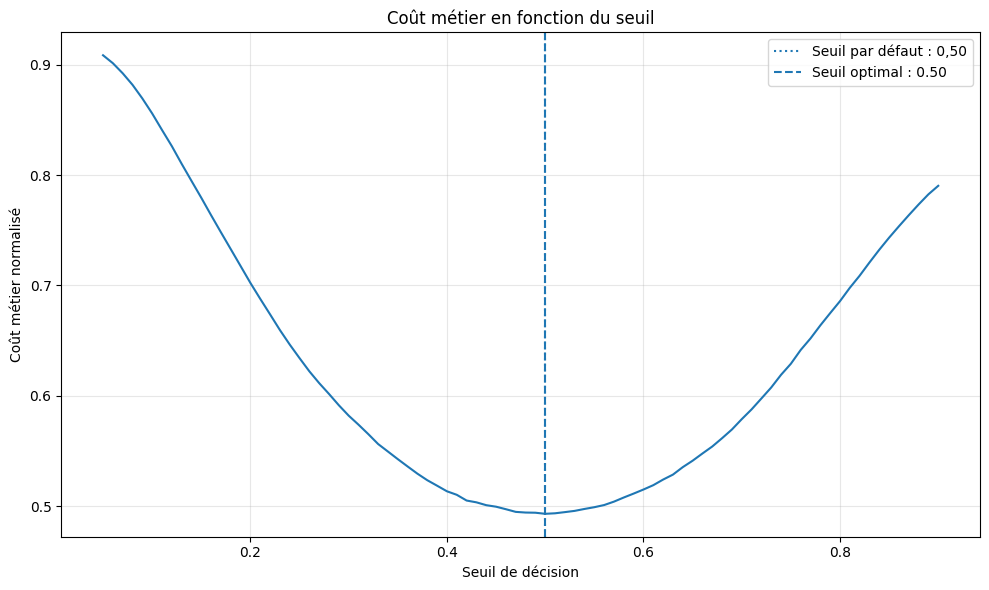

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df[
        "normalized_business_cost"
    ],
)

plt.axvline(
    x=0.50,
    linestyle=":",
    label="Seuil par défaut : 0,50",
)

plt.axvline(
    x=optimal_threshold,
    linestyle="--",
    label=(
        f"Seuil optimal : "
        f"{optimal_threshold:.2f}"
    ),
)

plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier normalisé")
plt.title("Coût métier en fonction du seuil")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

threshold_plot_path = (
    REPORTS_PATH / "business_cost_by_threshold.png"
)

plt.savefig(
    threshold_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Optimisation du seuil

In [54]:
threshold_results_path = (
    REPORTS_PATH / "threshold_results.csv"
)

threshold_results_df.to_csv(
    threshold_results_path,
    index=False,
)

In [55]:
default_threshold_metrics = evaluate_threshold(
    y_true=y_train,
    probabilities=optimized_oof_probabilities,
    threshold=0.50,
)

optimal_threshold_metrics = evaluate_threshold(
    y_true=y_train,
    probabilities=optimized_oof_probabilities,
    threshold=optimal_threshold,
)

In [56]:
with mlflow.start_run(
    run_name="08_LightGBM_Threshold_Optimization"
):

    mlflow.log_params(
        {
            "model": "LightGBM",
            "threshold_default": 0.50,
            "threshold_optimal": optimal_threshold,
            "fn_cost": FN_COST,
            "fp_cost": FP_COST,
            "threshold_min": thresholds.min(),
            "threshold_max": thresholds.max(),
            "threshold_step": 0.01,
        }
    )

    mlflow.log_metrics(
        {
            "default_business_cost": (
                default_threshold_metrics[
                    "business_cost"
                ]
            ),
            "default_normalized_business_cost": (
                default_threshold_metrics[
                    "normalized_business_cost"
                ]
            ),
            "default_recall": (
                default_threshold_metrics["recall"]
            ),
            "default_f1": (
                default_threshold_metrics["f1"]
            ),

            "optimal_business_cost": (
                optimal_threshold_metrics[
                    "business_cost"
                ]
            ),
            "optimal_normalized_business_cost": (
                optimal_threshold_metrics[
                    "normalized_business_cost"
                ]
            ),
            "optimal_recall": (
                optimal_threshold_metrics["recall"]
            ),
            "optimal_f1": (
                optimal_threshold_metrics["f1"]
            ),
        }
    )

    mlflow.log_artifact(str(threshold_plot_path))
    mlflow.log_artifact(str(threshold_results_path))

🏃 View run 08_LightGBM_Threshold_Optimization at: http://127.0.0.1:5000/#/experiments/1/runs/90ab630f8229431bb62bb954ecc3004b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Entrainement du modèle final

In [57]:
final_model = clone(best_lightgbm_model)

final_model.fit(
    X_train,
    y_train,
)

LGBMClassifier(colsample_bytree=np.float64(0.8413485977701479),
               learning_rate=np.float64(0.017398074711291726), max_depth=5,
               min_child_samples=99, n_estimators=855, n_jobs=-1, num_leaves=48,
               objective='binary', random_state=42,
               reg_alpha=np.float64(0.009456951897345888),
               reg_lambda=np.float64(9.673587794352073),
               scale_pos_weight=11.38710976837865,
               subsample=np.float64(0.9726559822580909), verbosity=-1)

### Évaluation finale sur le test

In [58]:
test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

In [59]:
test_metrics_default = evaluate_threshold(
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=0.50,
)

test_metrics_optimal = evaluate_threshold(
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=optimal_threshold,
)

In [60]:
final_test_results = pd.DataFrame(
    [
        {
            "configuration": "Seuil 0,50",
            **test_metrics_default,
        },
        {
            "configuration": (
                f"Seuil métier "
                f"{optimal_threshold:.2f}"
            ),
            **test_metrics_optimal,
        },
    ]
)

final_test_results

,configuration,threshold,roc_auc,accuracy,precision,recall,f1,business_cost,normalized_business_cost,tn,fp,fn,tp
0,"Seuil 0,50",0.5,0.789348,0.736972,0.190993,0.697885,0.299909,29677.0,0.482529,41861,14677,1500,3465
1,Seuil métier 0.50,0.5,0.789348,0.736972,0.190993,0.697885,0.299909,29677.0,0.482529,41861,14677,1500,3465


## Sauvegarde du modèle et du seuil

In [61]:
final_model_path = (
    MODELS_PATH / "final_credit_model.joblib"
)

threshold_path = (
    MODELS_PATH / "threshold_config.json"
)

joblib.dump(
    final_model,
    final_model_path,
)

['/Users/marinramananjaona/Projet Openclassrooms/Projet 6/mlops-credit-scoring/models/final_credit_model.joblib']

In [62]:
threshold_configuration = {
    "model_name": "LightGBM",
    "optimal_threshold": optimal_threshold,
    "false_negative_cost": FN_COST,
    "false_positive_cost": FP_COST,
}

with open(
    threshold_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        threshold_configuration,
        file,
        indent=4,
        ensure_ascii=False,
    )

## Run 9 - Modèle final

In [63]:
with mlflow.start_run(
    run_name="09_LightGBM_Final_Model"
):

    mlflow.log_params(
        {
            "model": "LightGBM",
            "optimal_threshold": optimal_threshold,
            "fn_cost": FN_COST,
            "fp_cost": FP_COST,
            "n_features": X_train.shape[1],
            **{
                f"best_{parameter}": value
                for parameter, value
                in best_lightgbm_params.items()
            },
        }
    )

    mlflow.log_metrics(
        {
            "test_roc_auc": (
                test_metrics_optimal["roc_auc"]
            ),
            "test_accuracy": (
                test_metrics_optimal["accuracy"]
            ),
            "test_precision": (
                test_metrics_optimal["precision"]
            ),
            "test_recall": (
                test_metrics_optimal["recall"]
            ),
            "test_f1": (
                test_metrics_optimal["f1"]
            ),
            "test_business_cost": (
                test_metrics_optimal[
                    "business_cost"
                ]
            ),
            "test_normalized_business_cost": (
                test_metrics_optimal[
                    "normalized_business_cost"
                ]
            ),
        }
    )

    mlflow.sklearn.log_model(
        sk_model=final_model,
        artifact_path="model",
        input_example=X_train.iloc[:5],
        registered_model_name=(
            "HomeCreditDefaultRiskModel"
        ),
    )

    mlflow.log_artifact(str(final_model_path))
    mlflow.log_artifact(str(threshold_path))
    mlflow.log_artifact(str(threshold_plot_path))

2026/07/24 10:09:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'HomeCreditDefaultRiskModel' already exists. Creating a new version of this model...
2026/07/24 10:10:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HomeCreditDefaultRiskModel, version 2


🏃 View run 09_LightGBM_Final_Model at: http://127.0.0.1:5000/#/experiments/1/runs/a0edc1badd4e4bdc8b6fc351c02f24d7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '2' of model 'HomeCreditDefaultRiskModel'.


[CV] END colsample_bytree=0.7810890415965769, learning_rate=0.17254716573280354, max_depth=8, min_child_samples=81, n_estimators=320, num_leaves=97, reg_alpha=0.0003161364550529618, reg_lambda=0.09445898178638688, scale_pos_weight=1, subsample=0.8603902541101232; total time= 2.7min
[CV] END colsample_bytree=0.6727680575448478, learning_rate=0.17160445029754812, max_depth=12, min_child_samples=23, n_estimators=541, num_leaves=23, reg_alpha=0.00012017974027309969, reg_lambda=0.009841952616421304, scale_pos_weight=17.080664652567975, subsample=0.8040533728088605; total time= 1.7min
[CV] END colsample_bytree=0.6927133821956726, learning_rate=0.04407984038169244, max_depth=8, min_child_samples=87, n_estimators=380, num_leaves=50, reg_alpha=0.000815042844436478, reg_lambda=1.7735036366245884, scale_pos_weight=5.693554884189325, subsample=0.8320238074122338; total time= 2.2min
[CV] END colsample_bytree=0.9878393575424482, learning_rate=0.06162682089644249, max_depth=16, min_child_samples=50, 

La fonction mlflow.sklearn.log_model permet d’enregistrer un modèle Scikit-learn dans MLflow ; un modèle peut ensuite être enregistré dans le Model Registry directement ou à partir de son URI.

## Afficher les résultats des runs depuis Python

In [ ]:
experiment = mlflow.get_experiment_by_name(
    experiment_name
)

runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ]
)

columns_to_display = [
    "run_id",
    "tags.mlflow.runName",
    "metrics.default_roc_auc",
    "metrics.optimal_business_cost",
    "metrics.validation_roc_auc",
    "metrics.holdout_roc_auc",
    "params.model"
]

existing_columns = [
    column
    for column in columns_to_display
    if column in runs.columns
]

display(
    runs[existing_columns]
    .sort_values(
        by=[
            column
            for column in [
                "metrics.default_roc_auc"
            ]
            if column in existing_columns
        ],
        ascending=False
    )
)

## Run 8 - Utiliser mlflow.autolog()

Une fois le logging manuel maîtrisé, tu peux tester :

In [ ]:
mlflow.sklearn.autolog(
    log_input_examples=True,
    log_model_signatures=True,
    log_models=True,
    silent=False
)

In [ ]:
with mlflow.start_run(
    run_name="Logistic_autolog_test"
):

    test_model = LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    test_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            test_model
        )
    ])

    test_pipeline.fit(
        X_train,
        y_train
    )

    probabilities = test_pipeline.predict_proba(
        X_valid
    )[:, 1]

    mlflow.log_metric(
        "custom_validation_auc",
        roc_auc_score(
            y_valid,
            probabilities
        )
    )

MLflow propose à la fois le logging manuel et l’autologging ; le logging manuel donne davantage de contrôle sur les métriques métier, tags et artefacts personnalisés.

Après ce test, désactive l’autologging pour éviter des logs involontaires :

In [ ]:
mlflow.sklearn.autolog(
    disable=True
)

## Feature importance

In [64]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": final_model.feature_importances_,
        }
    )
    .sort_values(
        by="importance",
        ascending=False,
    )
)

feature_importance.head(20)

,feature,importance
244,CREDIT_ANNUITY_RATIO,760
250,EXT_SOURCE_MEAN,474
9,DAYS_BIRTH,448
294,BUREAU_BUREAU_DEBT_CREDIT_RATIO_MAX,385
30,EXT_SOURCE_1,379
32,EXT_SOURCE_3,379
6,AMT_ANNUITY,374
245,GOODS_CREDIT_RATIO,312
430,POS_CNT_INSTALMENT_FUTURE_MEAN,282
264,BUREAU_DAYS_CREDIT_ENDDATE_MAX,268


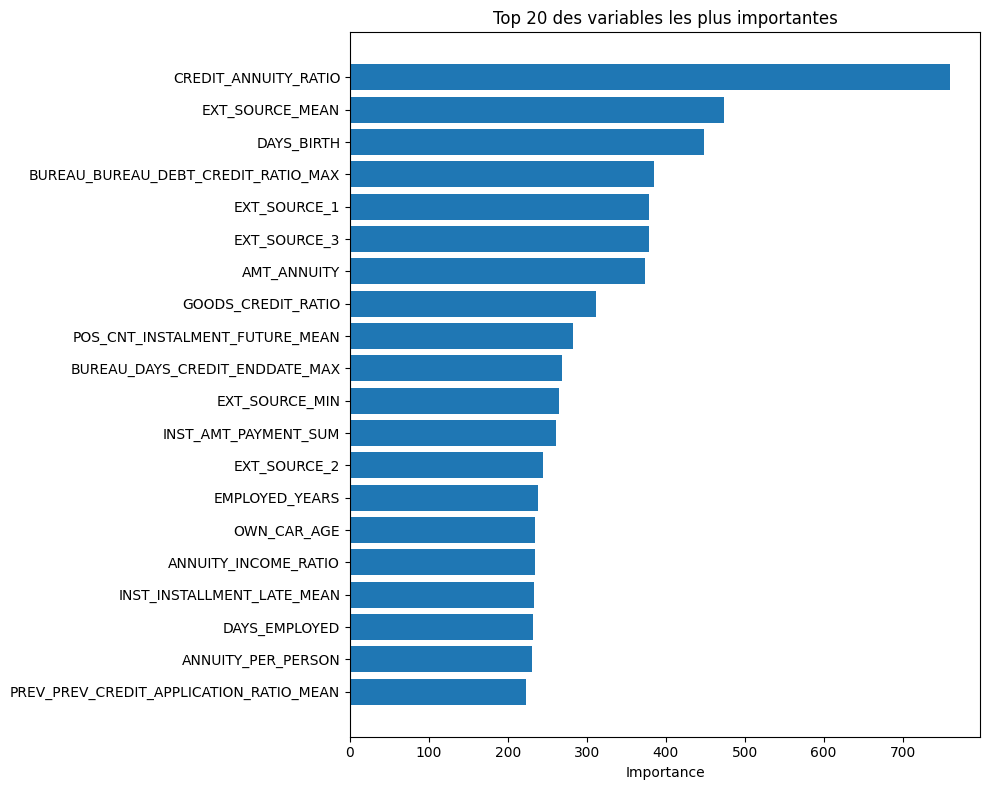

[CV] END colsample_bytree=0.8640786061708983, learning_rate=0.010213944061855218, max_depth=-1, min_child_samples=58, n_estimators=774, num_leaves=73, reg_alpha=0.00998400658032865, reg_lambda=0.001587487876280495, scale_pos_weight=17.080664652567975, subsample=0.7782266451527922; total time= 7.5min
[CV] END colsample_bytree=0.9878393575424482, learning_rate=0.06162682089644249, max_depth=16, min_child_samples=50, n_estimators=456, num_leaves=29, reg_alpha=0.0006704010646472256, reg_lambda=0.0011674886157243493, scale_pos_weight=1, subsample=0.9202856692538302; total time= 2.0min
[CV] END colsample_bytree=0.6905541708337954, learning_rate=0.1327160497040489, max_depth=12, min_child_samples=43, n_estimators=332, num_leaves=62, reg_alpha=0.007146464833933034, reg_lambda=0.7528462475095737, scale_pos_weight=1, subsample=0.9053621624183225; total time= 2.0min
[CV] END colsample_bytree=0.664151756338451, learning_rate=0.0840608420892158, max_depth=5, min_child_samples=51, n_estimators=760, 

In [65]:
plt.figure(figsize=(10,8))

top_features = feature_importance.head(20)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title(
    "Top 20 des variables les plus importantes"
)

plt.tight_layout()

plt.show()

## Interprétation de la Feature Importance

Le graphique d'importance des variables met en évidence les variables les plus utilisées par le modèle LightGBM lors de la construction des arbres de décision.

Les variables les plus importantes sont :

- **CREDIT_ANNUITY_RATIO**, qui mesure le rapport entre le montant du crédit et les annuités de remboursement ;
- **EXT_SOURCE_MEAN**, construit à partir des scores externes fournis par Home Credit ;
- **DAYS_BIRTH**, représentant l'âge du client ;
- **BUREAU_BUREAU_DEBT_CREDIT_RATIO_MAX**, décrivant le niveau maximal d'endettement observé dans l'historique bancaire ;
- **EXT_SOURCE_1** et **EXT_SOURCE_3**, qui sont également des scores de risque externes.

On observe également que plusieurs variables créées lors de la phase de feature engineering apparaissent parmi les plus importantes (ratios financiers, agrégations issues des tables Bureau, Installments et Previous Application). Cela confirme que les nouvelles variables construites apportent une information pertinente pour améliorer la prédiction du risque de défaut.

Enfin, les variables liées aux scores externes (EXT_SOURCE) représentent une part importante des variables les plus influentes, ce qui confirme leur fort pouvoir prédictif dans le jeu de données Home Credit.

## SHAP

In [68]:
explainer = shap.TreeExplainer(final_model)

sample = X_train.sample(
    1000,
    random_state=RANDOM_STATE,
)

shap_values = explainer.shap_values(sample)

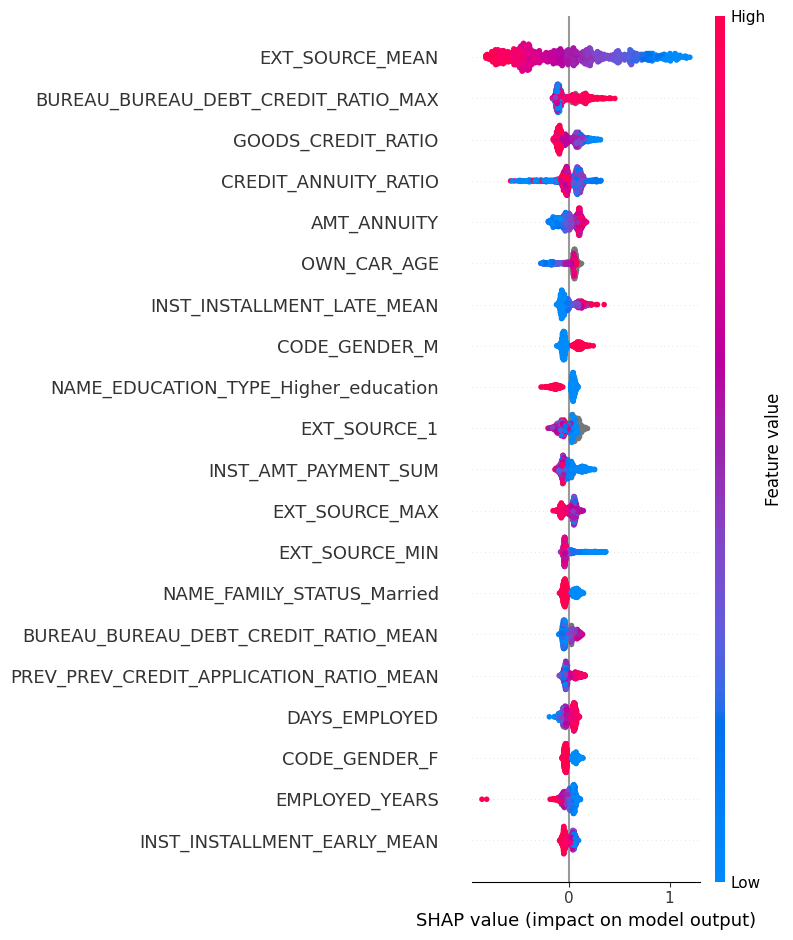

In [69]:
plt.figure()

shap.summary_plot(
    shap_values,
    sample,
    show=False,
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH/"shap_summary.png",
    dpi=150
)

plt.show()

In [70]:
mlflow.log_artifact(
    str(REPORTS_PATH/"shap_summary.png")
)

## Interprétation des valeurs SHAP

Le graphique SHAP permet d'aller plus loin que la Feature Importance en expliquant l'influence de chaque variable sur les prédictions du modèle.

Chaque point représente un client.

- La couleur indique la valeur de la variable (bleu = valeur faible, rouge = valeur élevée).
- La position horizontale représente la contribution de cette variable à la prédiction.
- Une valeur SHAP positive augmente la probabilité prédite de défaut.
- Une valeur SHAP négative diminue cette probabilité.

Les principales observations sont les suivantes :

- **EXT_SOURCE_MEAN** est la variable la plus influente. Les valeurs élevées (points rouges) déplacent majoritairement les prédictions vers des valeurs SHAP négatives, ce qui signifie qu'un bon score externe réduit fortement le risque de défaut. À l'inverse, des scores faibles (points bleus) augmentent la probabilité de défaut.

- **BUREAU_BUREAU_DEBT_CREDIT_RATIO_MAX** présente une relation inverse. Des ratios d'endettement élevés augmentent le risque de défaut tandis que des ratios faibles contribuent à diminuer ce risque.

- **GOODS_CREDIT_RATIO** et **CREDIT_ANNUITY_RATIO** influencent également fortement les décisions du modèle. Les différents ratios financiers construits lors du feature engineering permettent donc au modèle de mieux distinguer les profils de clients.

- Les variables **AMT_ANNUITY**, **OWN_CAR_AGE** et **INST_INSTALLMENT_LATE_MEAN** montrent qu'un niveau d'annuité élevé, un véhicule ancien ou un historique de retards de paiement ont également un impact sur la prédiction.

- Les variables issues de l'historique bancaire (**BUREAU**), des remboursements (**INSTALLMENTS**) et des précédentes demandes de crédit (**PREVIOUS APPLICATION**) apparaissent parmi les plus influentes, ce qui confirme l'intérêt d'avoir enrichi le jeu de données initial avec ces informations.

Dans l'ensemble, les résultats SHAP montrent que le modèle ne s'appuie pas uniquement sur les caractéristiques démographiques du client mais exploite principalement son comportement financier, son historique de crédit et plusieurs indicateurs construits lors du feature engineering.

## Différence Feature Importance et SHAP
La Feature Importance et SHAP ne donnent pas exactement le même classement des variables. La Feature Importance mesure la fréquence et le gain des variables lors de la construction des arbres, tandis que SHAP mesure leur contribution réelle aux prédictions. Il est donc normal que certaines variables changent de position entre les deux analyses.